In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load the Cora.cites dataset
def load_cora_cites(cites_file_path):
    # Read the Cora.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by='Source')
    nodes = pd.unique(df_sorted[['Source', 'Target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['Source']]
        target_idx = node_index[row['Target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# Load the Cora.content dataset
def load_cora_content(file_path):
    df = pd.read_csv(file_path, sep='\t', header=None, names=['paper_id'] + [f'feature_{i}' for i in range(1433)] + ['label'])
    df_sorted = df.sort_values(by='paper_id', ascending=True)
    paper_ids = df_sorted['paper_id'].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids

# Paths to the datasets
cites_file_path = '/content/drive/MyDrive/cora.csv'
content_file_path = '/content/drive/MyDrive/cora.content'

# Load the similarity matrices
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes = load_cora_content(content_file_path)

# Ensure the node ordering is consistent for combining similarity matrices
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# Combine the similarity matrices using the weighted sum
alpha = 0.6  # Weight for the Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values

# Convert the combined similarity matrix to a DataFrame for better readability
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# Print the combined similarity matrix (first 5 rows for inspection)
print(combined_sim_df.head())
print(jaccard_sim_df.head())
print(content_sim_df.head())
print(f"Shape of Combined Similarity Matrix: {combined_sim_df.shape}")


      35        40        114       117       128       130       164      \
35   1.000000  0.045735  0.025820  0.040000  0.040000  0.000000  0.000000   
40   0.045735  1.000000  0.054433  0.021082  0.042164  0.040202  0.000000   
114  0.025820  0.054433  1.000000  0.067925  0.093500  0.038255  0.026491   
117  0.040000  0.021082  0.067925  1.000000  0.130000  0.069717  0.000000   
128  0.040000  0.042164  0.093500  0.130000  1.000000  0.157208  0.020520   

      288       424       434      ...   1154232   1154233   1154251  \
35   0.039036  0.021082  0.000000  ...  0.058554  0.063246  0.000000   
40   0.102869  0.022222  0.040202  ...  0.020574  0.000000  0.041148   
114  0.000000  0.000000  0.024618  ...  0.000000  0.000000  0.025198   
117  0.039036  0.042164  0.000000  ...  0.000000  0.000000  0.019518   
128  0.019518  0.021082  0.038139  ...  0.019518  0.000000  0.000000   

      1154276   1154459  1154500   1154520   1154524   1154525   1155073  
35   0.019069  0.146059  0.02

GAT IMPLEMENTATION WITHOUT NOVELTY

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# ✅ **Load Cora.cites Dataset**
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by='Source')
    nodes = pd.unique(df_sorted[['Source', 'Target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['Source']]
        target_idx = node_index[row['Target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# ✅ **Load Cora.content Dataset**
def load_cora_content(file_path):
    df = pd.read_csv(file_path, sep='\t', header=None, names=['paper_id'] + [f'feature_{i}' for i in range(1433)] + ['label'])
    df_sorted = df.sort_values(by='paper_id', ascending=True)
    paper_ids = df_sorted['paper_id'].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted['label'].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# ✅ **Construct Graph from Combined Similarity Matrix**
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# ✅ **Convert to PyTorch Geometric Format**
def convert_to_pyg(G, node_index, features, labels):
    data = from_networkx(G)

    node_list = list(G.nodes())

    # Map node indices to feature vectors
    feature_indices = [node_index[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Convert labels to numerical values
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index[node]]] for node in node_list])

    data.x = node_features
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data

# ✅ **Define GAT Model**
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        embeddings = x  # Second-to-last layer embeddings
        x = self.conv2(x, edge_index)
        return x, embeddings

# ✅ **Train the Model**
def train(model, data, train_mask, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ **Test the Model**
@torch.no_grad()
def test(model, data, train_mask, test_mask):
    model.eval()
    out, _ = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ **Compute Evaluation Metrics**
def compute_metrics(graph, embeddings, cluster_labels, true_labels):
    # Modularity
    def compute_modularity(graph, cluster_labels):
        modularity = 0.0
        m = graph.number_of_edges()
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            l_c = subgraph.number_of_edges()
            d_c = sum(dict(graph.degree(nodes_in_cluster)).values())
            modularity += (l_c / m) - (d_c / (2 * m)) ** 2
        return modularity

    # Conductance
    def compute_conductance(graph, cluster_labels):
        conductance = 0.0
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            cut_size = nx.cut_size(graph, nodes_in_cluster)
            volume = sum(dict(graph.degree(nodes_in_cluster)).values())
            if volume > 0:
                conductance += cut_size / volume
        return conductance / len(set(cluster_labels))

    modularity = compute_modularity(graph, cluster_labels)
    conductance = compute_conductance(graph, cluster_labels)
    clustering_coefficient = nx.average_clustering(graph)
    silhouette = silhouette_score(embeddings, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)

    return {
        "Modularity": modularity,
        "Conductance": conductance,
        "Clustering Coefficient": clustering_coefficient,
        "Silhouette Score": silhouette,
        "NMI": nmi,
        "ARI": ari
    }

# ✅ **Main Workflow**
def main():
    # Paths to datasets
    cites_file_path = '/content/drive/MyDrive/cora.csv'
    content_file_path = '/content/drive/MyDrive/cora.content'

    # Load datasets
    jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
    content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

    # Ensure consistent node ordering
    common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
    jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
    content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

    # Combine similarity matrices
    alpha = 0.6  # Weight for Jaccard similarity
    combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
    combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

    # Construct graph
    threshold = 0.2  # Adjust based on required edge density
    G = construct_graph(combined_sim_df, threshold)

    # Convert to PyTorch Geometric format
    node_index = {node: idx for idx, node in enumerate(common_nodes)}
    data_pyg = convert_to_pyg(G, node_index, features, labels)

    # Train/Test split
    num_nodes = data_pyg.num_nodes
    train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_nodes] = True
    test_mask[test_nodes] = True

    # Define model, optimizer, and loss function
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_pyg = data_pyg.to(device)
    model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # Train the model
    for epoch in range(100):
        loss = train(model, data_pyg, train_mask, optimizer, criterion)
        if epoch % 10 == 0:
            acc_train, acc_test = test(model, data_pyg, train_mask, test_mask)
            print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

    # Extract second-to-last layer embeddings
    @torch.no_grad()
    def get_embeddings():
        model.eval()
        _, embeddings = model(data_pyg.x, data_pyg.edge_index)
        return embeddings.cpu().numpy()

    embeddings = get_embeddings()

    # Apply k-means clustering
    kmeans = KMeans(n_clusters=len(set(labels)), random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Compute evaluation metrics
    metrics = compute_metrics(G, embeddings, cluster_labels, data_pyg.y.cpu().numpy())

    # Print metrics
    print("\n🔹 Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"🔹 {metric}: {value:.4f}")

# Run the main workflow
if __name__ == "__main__":
    main()

Epoch 0: Loss: 1.9921, Train Acc: 0.4114, Test Acc: 0.3856
Epoch 10: Loss: 1.3412, Train Acc: 0.8615, Test Acc: 0.7786
Epoch 20: Loss: 1.1231, Train Acc: 0.9127, Test Acc: 0.8229
Epoch 30: Loss: 1.0371, Train Acc: 0.9428, Test Acc: 0.8155
Epoch 40: Loss: 0.9733, Train Acc: 0.9589, Test Acc: 0.7989
Epoch 50: Loss: 0.9504, Train Acc: 0.9649, Test Acc: 0.8026
Epoch 60: Loss: 0.9113, Train Acc: 0.9686, Test Acc: 0.8063
Epoch 70: Loss: 0.9204, Train Acc: 0.9691, Test Acc: 0.7934
Epoch 80: Loss: 0.9137, Train Acc: 0.9755, Test Acc: 0.7970
Epoch 90: Loss: 0.8809, Train Acc: 0.9728, Test Acc: 0.7989

🔹 Evaluation Metrics:
🔹 Modularity: 0.0006
🔹 Conductance: 0.9810
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.2754
🔹 NMI: 0.6860
🔹 ARI: 0.6487


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# ✅ **Load CiteSeer.cites Dataset**
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# ✅ **Load CiteSeer.content Dataset**
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values  # First column: Paper IDs
    features = df_sorted.iloc[:, 1:-1].values  # Middle columns: Features
    labels = df_sorted.iloc[:, -1].values  # Last column: Labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# ✅ **Construct Graph from Combined Similarity Matrix**
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# ✅ **Convert to PyTorch Geometric Format**
def convert_to_pyg(G, node_index, features, labels):
    data = from_networkx(G)

    node_list = list(G.nodes())

    # Map node indices to feature vectors
    feature_indices = [node_index[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Convert labels to numerical values
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index[node]]] for node in node_list])

    data.x = node_features
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data

# ✅ **Define GAT Model**
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        embeddings = x  # Second-to-last layer embeddings
        x = self.conv2(x, edge_index)
        return x, embeddings

# ✅ **Train the Model**
def train(model, data, train_mask, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ **Test the Model**
@torch.no_grad()
def test(model, data, train_mask, test_mask):
    model.eval()
    out, _ = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ **Compute Evaluation Metrics**
def compute_metrics(graph, embeddings, cluster_labels, true_labels):
    # Modularity
    def compute_modularity(graph, cluster_labels):
        modularity = 0.0
        m = graph.number_of_edges()
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            l_c = subgraph.number_of_edges()
            d_c = sum(dict(graph.degree(nodes_in_cluster)).values())
            modularity += (l_c / m) - (d_c / (2 * m)) ** 2
        return modularity

    # Conductance
    def compute_conductance(graph, cluster_labels):
        conductance = 0.0
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            cut_size = nx.cut_size(graph, nodes_in_cluster)
            volume = sum(dict(graph.degree(nodes_in_cluster)).values())
            if volume > 0:
                conductance += cut_size / volume
        return conductance / len(set(cluster_labels))

    modularity = compute_modularity(graph, cluster_labels)
    conductance = compute_conductance(graph, cluster_labels)
    clustering_coefficient = nx.average_clustering(graph)
    silhouette = silhouette_score(embeddings, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)

    return {
        "Modularity": modularity,
        "Conductance": conductance,
        "Clustering Coefficient": clustering_coefficient,
        "Silhouette Score": silhouette,
        "NMI": nmi,
        "ARI": ari
    }

# ✅ **Main Workflow**
def main():
    # Paths to datasets
    cites_file_path = '/content/drive/MyDrive/citeseer.cites'
    content_file_path = '/content/drive/MyDrive/citeseer.content'

    # Load datasets
    jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
    content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

    # Ensure consistent node ordering
    common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
    jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
    content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

    # Combine similarity matrices
    alpha = 0.6  # Weight for Jaccard similarity
    combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
    combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

    # Construct graph
    threshold = 0.2  # Adjust based on required edge density
    G = construct_graph(combined_sim_df, threshold)

    # Convert to PyTorch Geometric format
    node_index = {node: idx for idx, node in enumerate(common_nodes)}
    data_pyg = convert_to_pyg(G, node_index, features, labels)

    # Train/Test split
    num_nodes = data_pyg.num_nodes
    train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_nodes] = True
    test_mask[test_nodes] = True

    # Define model, optimizer, and loss function
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_pyg = data_pyg.to(device)
    model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # Train the model
    for epoch in range(100):
        loss = train(model, data_pyg, train_mask, optimizer, criterion)
        if epoch % 10 == 0:
            acc_train, acc_test = test(model, data_pyg, train_mask, test_mask)
            print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

    # Extract second-to-last layer embeddings
    @torch.no_grad()
    def get_embeddings():
        model.eval()
        _, embeddings = model(data_pyg.x, data_pyg.edge_index)
        return embeddings.cpu().numpy()

    embeddings = get_embeddings()

    # Apply k-means clustering
    kmeans = KMeans(n_clusters=len(set(labels)), random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Compute evaluation metrics
    metrics = compute_metrics(G, embeddings, cluster_labels, data_pyg.y.cpu().numpy())

    # Print metrics
    print("\n🔹 Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"🔹 {metric}: {value:.4f}")

# Run the main workflow
if __name__ == "__main__":
    main()

GRAPH AFTER COMBINED SIMILARITY METRICS


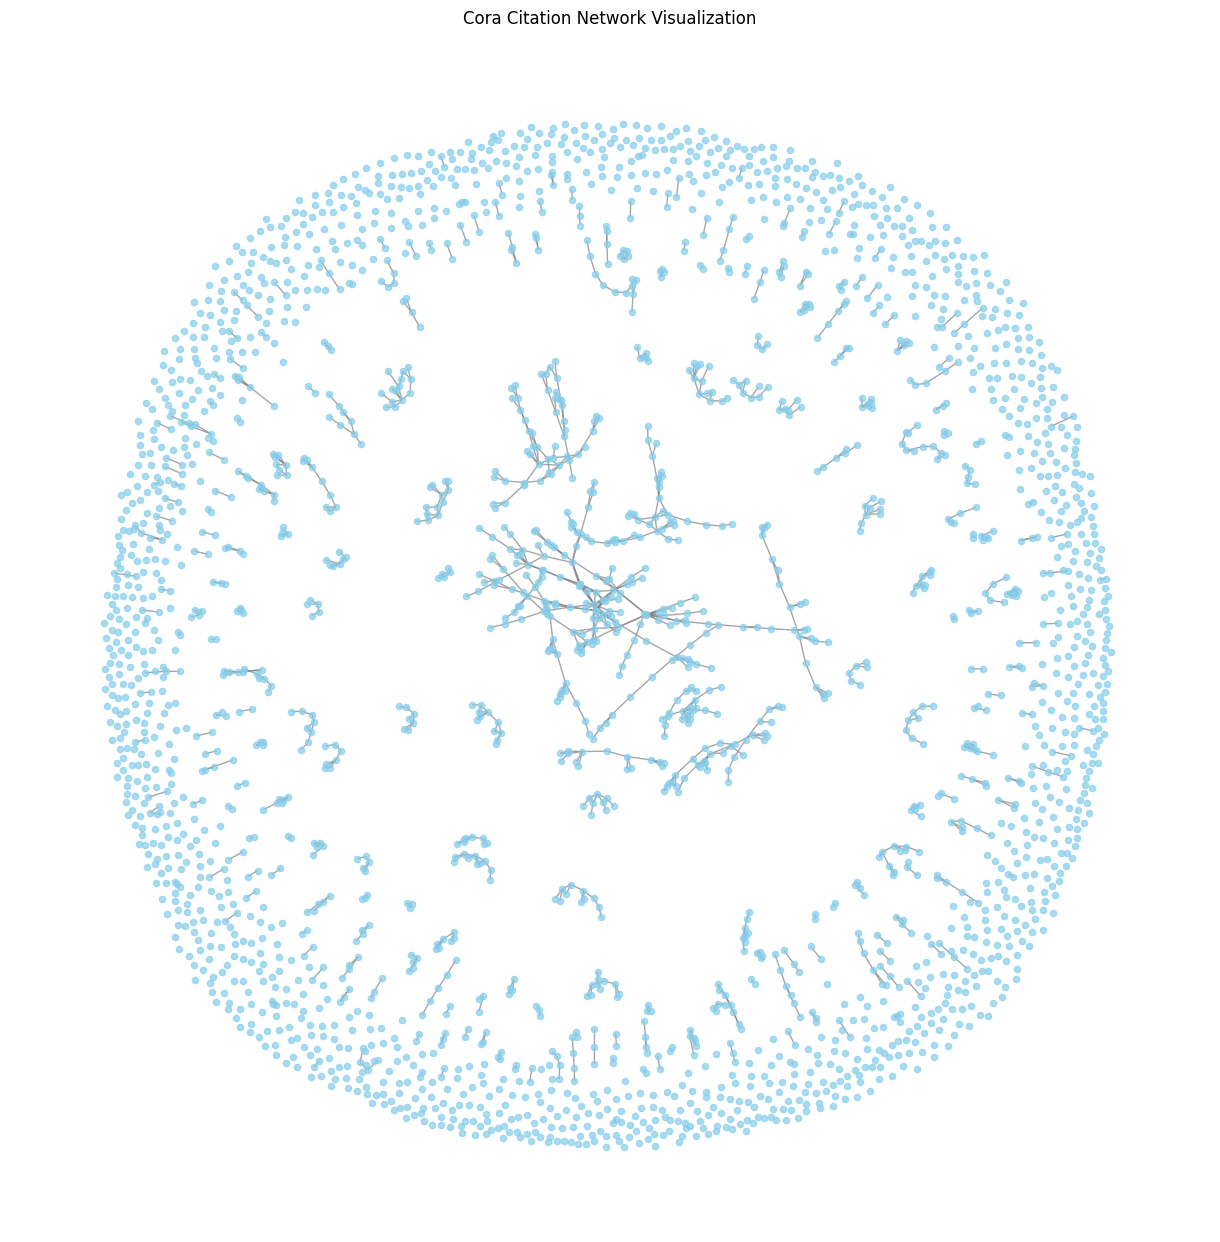

In [ ]:
import matplotlib.pyplot as plt
# Visualize the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Use spring layout for node positioning
nx.draw(G, pos, with_labels=False, node_size=20, node_color="skyblue", edge_color="gray", alpha=0.7)
plt.title("Cora Citation Network Visualization")
plt.show()


GRAPH AFTER K CLIQUES

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.community import k_clique_communities

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

🔹 k-Clique Membership Distribution:
In k-Clique (1): 23
Not in k-Clique (0): 2685


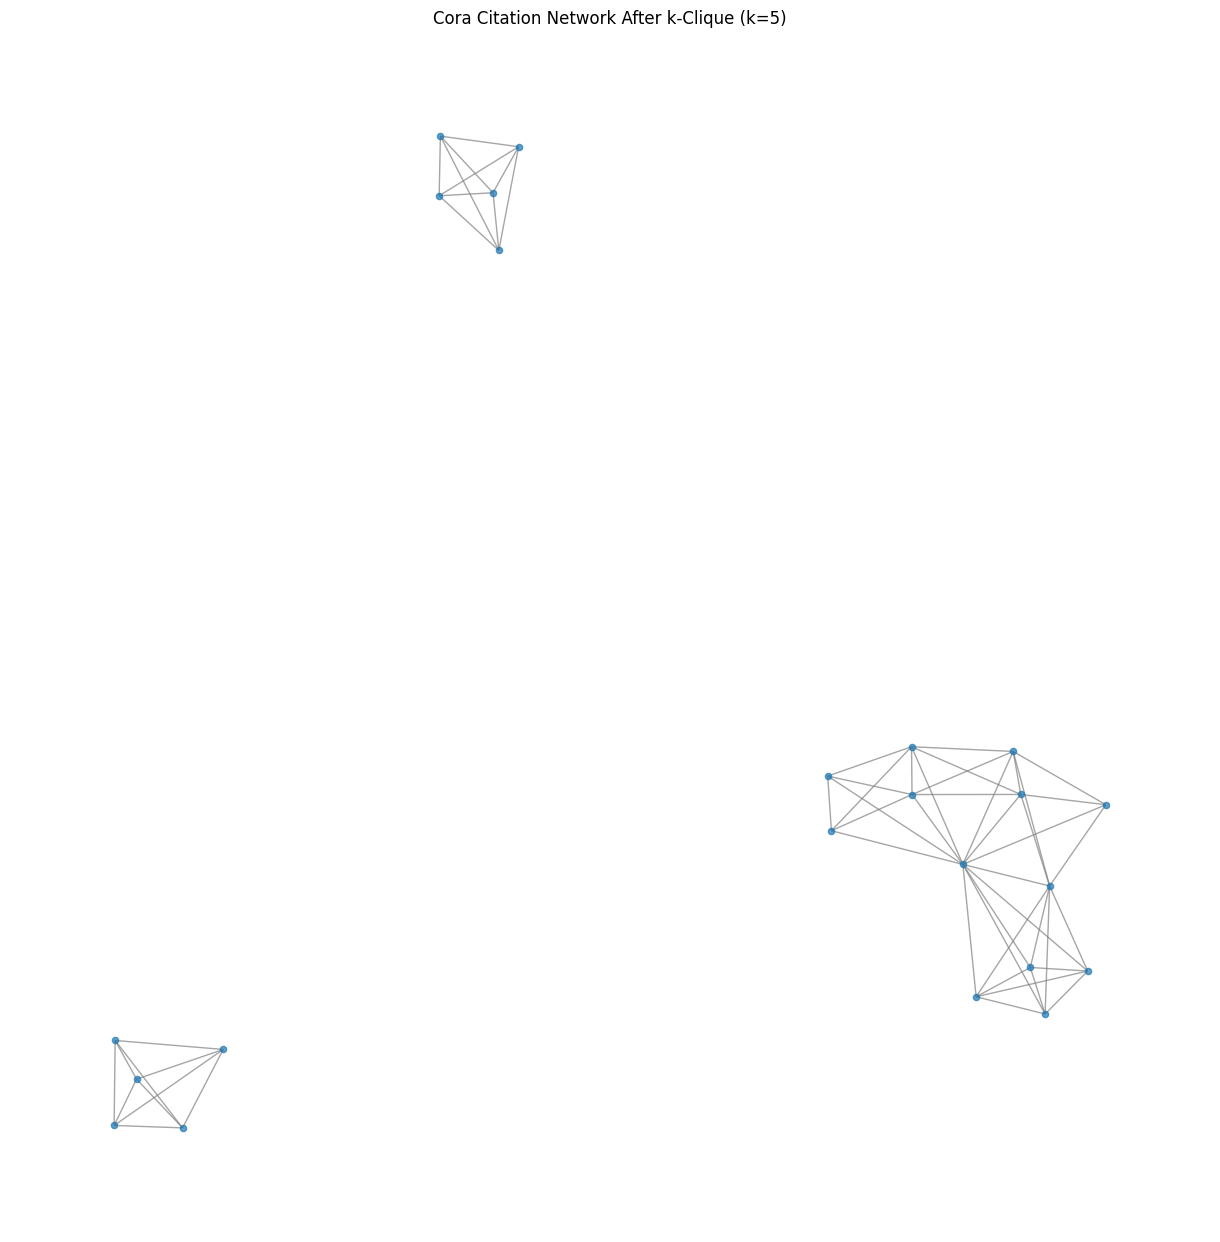

✅ Number of nodes in G_clique: 23
✅ Number of edges in G_clique: 58


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import k_clique_communities

# Detect k-clique communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Membership Distribution
k_clique_membership = {node: 0 for node in G.nodes()}  # Initialize all nodes as non-members (0)

for community in communities:
    for node in community:
        k_clique_membership[node] = 1  # Mark nodes in k-clique as members (1)

# 🔹 Count the Distribution
membership_distribution = {
    "In k-Clique (1)": sum(1 for v in k_clique_membership.values() if v == 1),
    "Not in k-Clique (0)": sum(1 for v in k_clique_membership.values() if v == 0)
}

# 🔹 Print Distribution
print("🔹 k-Clique Membership Distribution:")
for category, count in membership_distribution.items():
    print(f"{category}: {count}")

# 🔹 Optional: Visualize the k-Clique Graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_clique, seed=42)
nx.draw(G_clique, pos, with_labels=False, node_size=20, edge_color="gray", alpha=0.7)
plt.title(f"Cora Citation Network After k-Clique (k={k})")
plt.show()

# 🔹 Print Graph Information
print(f"✅ Number of nodes in G_clique: {G_clique.number_of_nodes()}")
print(f"✅ Number of edges in G_clique: {G_clique.number_of_edges()}")


APPLYING DIFFERENT CENTRALITY MEASURES

*   Eigenvector Centrality	📌 If you want to prioritize the most influential nodes that are deeply connected in cliques.	Captures overall importance in tightly connected clusters.

*   PageRank	📌 If you want to prioritize globally influential nodes that spread information.	Balances direct influence and overall reach in the graph.

*   Degree Centrality	📌 If you want to simply focus on the most connected nodes.	Good baseline but too local

*  Betweenness Centrality	❌ Not ideal for this task.	Focuses on "bridging" nodes instead of clique leaders.

*  Closeness Centrality	❌ Also not ideal.	Measures how fast a node reaches others, but this doesn't strongly relate to k-cliques.


In [ ]:
import networkx as nx

# 🔹 Compute Centrality Measures
degree_centrality = nx.degree_centrality(G_clique)
betweenness_centrality = nx.betweenness_centrality(G_clique)
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
closeness_centrality = nx.closeness_centrality(G_clique)
pagerank_centrality = nx.pagerank(G_clique, alpha=0.85)  # PageRank with default damping factor 0.85

# 🔹 Normalize Centrality Scores (Range [0,1])
def normalize_centrality(centrality_dict):
    max_centrality = max(centrality_dict.values()) if centrality_dict else 1
    return {node: score / max_centrality for node, score in centrality_dict.items()}

degree_centrality_norm = normalize_centrality(degree_centrality)
betweenness_centrality_norm = normalize_centrality(betweenness_centrality)
eigenvector_centrality_norm = normalize_centrality(eigenvector_centrality)
closeness_centrality_norm = normalize_centrality(closeness_centrality)
pagerank_centrality_norm = normalize_centrality(pagerank_centrality)

# 🔹 Print Top 5 Influential Nodes for Each Measure
def get_top_nodes(centrality_dict, top_n=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("🔹 Top 5 Nodes by Degree Centrality:", get_top_nodes(degree_centrality_norm))
print("🔹 Top 5 Nodes by Betweenness Centrality:", get_top_nodes(betweenness_centrality_norm))
print("🔹 Top 5 Nodes by Eigenvector Centrality:", get_top_nodes(eigenvector_centrality_norm))
print("🔹 Top 5 Nodes by Closeness Centrality:", get_top_nodes(closeness_centrality_norm))
print("🔹 Top 5 Nodes by PageRank Centrality:", get_top_nodes(pagerank_centrality_norm))


🔹 Top 5 Nodes by Degree Centrality: [(1137466, 1.0), (248431, 0.5), (1130856, 0.5), (561238, 0.5), (1153280, 0.4375)]
🔹 Top 5 Nodes by Betweenness Centrality: [(1137466, 1.0), (56115, 0.4475138121546961), (1153280, 0.09668508287292821), (1152421, 0.09668508287292821), (1154459, 0.09668508287292821)]
🔹 Top 5 Nodes by Eigenvector Centrality: [(1137466, 1.0), (248431, 0.6183880288884168), (1130856, 0.5775259438048218), (561238, 0.5775259438048217), (119712, 0.5229948513251255)]
🔹 Top 5 Nodes by Closeness Centrality: [(1137466, 1.0), (1130856, 0.7222222222222223), (561238, 0.7222222222222223), (248431, 0.7027027027027026), (56115, 0.6842105263157895)]
🔹 Top 5 Nodes by PageRank Centrality: [(1137466, 1.0), (64319, 0.539766294392847), (27606, 0.5210179196166315), (5075, 0.4925805918978963), (289781, 0.48835983727867655)]


✅ k=3, Louvain Modularity Score: 0.9797
✅ k=4, Louvain Modularity Score: 0.9430
✅ k=5, Louvain Modularity Score: 0.6122
✅ k=6, Louvain Modularity Score: -0.0000
✅ k=7, Louvain Modularity Score: 0.0000


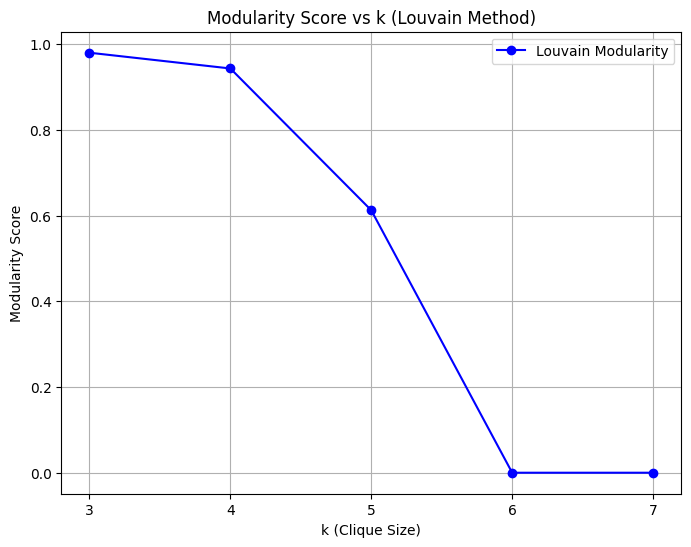

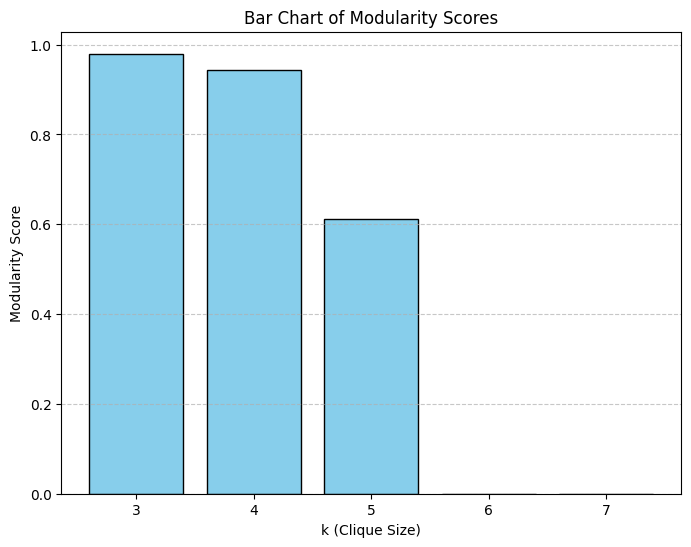

KeyError: 7

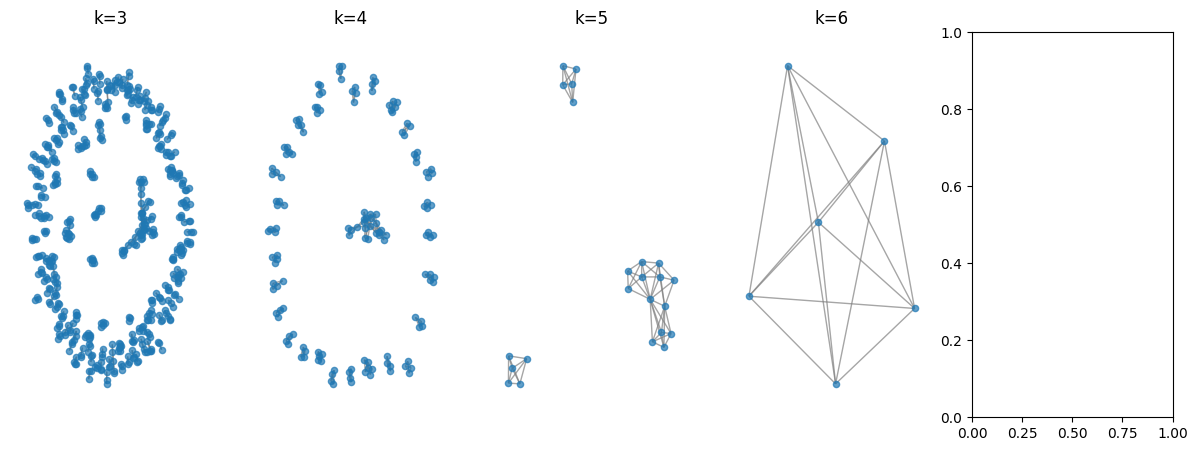

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community  # ✅ Correct import for Louvain
from networkx.algorithms.community import k_clique_communities
import numpy as np

# ✅ Function to detect k-clique communities and compute Louvain modularity
def compute_louvain_modularity(G, k_values):
    modularity_scores = {}
    G_cliques = {}  # Store subgraphs for visualization

    for k in k_values:
        # Detect k-clique communities
        communities = list(k_clique_communities(G, k))

        # ✅ Create a subgraph with nodes in k-cliques
        G_clique = nx.Graph()
        node_community_map = {}  # Track which node belongs to which community

        for i, community_set in enumerate(communities):
            G_clique.add_nodes_from(community_set)
            for u in community_set:
                for v in community_set:
                    if u != v and G.has_edge(u, v):
                        G_clique.add_edge(u, v, weight=G[u][v].get("weight", 1))
                node_community_map[u] = i  # Assign community index to node

        # ✅ Apply Louvain community detection if there are nodes
        if G_clique.number_of_nodes() > 0:
            partition = community.best_partition(G_clique)  # ✅ FIX: Corrected Louvain function
            modularity_score = community.modularity(partition, G_clique)  # ✅ Compute modularity
            modularity_scores[k] = modularity_score
            G_cliques[k] = G_clique  # Store subgraph
        else:
            modularity_scores[k] = 0  # If no communities found, modularity is 0

        print(f"✅ k={k}, Louvain Modularity Score: {modularity_scores[k]:.4f}")

    return modularity_scores, G_cliques

# ✅ Define range of k values
k_values = range(3, 8)  # k from 3 to 7

# ✅ Compute modularity scores and subgraphs
modularity_scores, G_cliques = compute_louvain_modularity(G, k_values)

# ✅ Convert dictionary to lists for plotting
modularity_values = list(modularity_scores.values())

# ✅ Visualization 1: Line Plot (Modularity vs k)
plt.figure(figsize=(8, 6))
plt.plot(k_values, modularity_values, marker='o', linestyle='-', color='b', label="Louvain Modularity")
plt.xlabel("k (Clique Size)")
plt.ylabel("Modularity Score")
plt.title("Modularity Score vs k (Louvain Method)")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# ✅ Visualization 2: Bar Chart (Modularity Comparison)
plt.figure(figsize=(8, 6))
plt.bar(k_values, modularity_values, color="skyblue", edgecolor="black")
plt.xlabel("k (Clique Size)")
plt.ylabel("Modularity Score")
plt.title("Bar Chart of Modularity Scores")
plt.xticks(k_values)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# ✅ Visualization 3: Network Visualization of k-Clique Communities
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 5))

for i, k in enumerate(k_values):
    if G_cliques[k].number_of_nodes() > 0:  # Ensure there is a subgraph
        ax = axes[i]
        pos = nx.spring_layout(G_cliques[k], seed=42)
        nx.draw(G_cliques[k], pos, ax=ax, node_size=20, edge_color="gray", alpha=0.7)
        ax.set_title(f"k={k}")

plt.suptitle("Network Visualization of k-Clique Communities")
plt.show()
0

GAT IMPLEMENTATION

k=3

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 3  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])


eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Fix: Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Fix: Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels (Fix indexing issue)
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# ✅ Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)


# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")


Epoch 0: Loss: 2.4498, Train Acc: 0.4432, Test Acc: 0.4133
Epoch 10: Loss: 1.1956, Train Acc: 0.8966, Test Acc: 0.7786
Epoch 20: Loss: 1.0619, Train Acc: 0.9441, Test Acc: 0.7970
Epoch 30: Loss: 0.9610, Train Acc: 0.9589, Test Acc: 0.8137
Epoch 40: Loss: 0.9281, Train Acc: 0.9691, Test Acc: 0.8100
Epoch 50: Loss: 0.9071, Train Acc: 0.9681, Test Acc: 0.8173
Epoch 60: Loss: 0.9127, Train Acc: 0.9732, Test Acc: 0.8137
Epoch 70: Loss: 0.9099, Train Acc: 0.9718, Test Acc: 0.8100
Epoch 80: Loss: 0.8724, Train Acc: 0.9732, Test Acc: 0.8100
Epoch 90: Loss: 0.8730, Train Acc: 0.9755, Test Acc: 0.8044


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 2708
First 10 nodes: [35, 40, 114, 117, 128, 130, 164, 288, 424, 434]
Shape of second-last layer embeddings: (2708, 64)
Similarity graph has 2708 nodes and 618112 edges

=== Louvain Community Detection Results ===
Number of communities detected: 6
Modularity Score: 0.6032
NMI Score: 0.8043
ARI Score: 0.8184
Conductance Score: 0.1741
Clustering Coefficient: 0.7638
Silhouette Score: 0.2370


K MEANS


In [ ]:
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=7)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")



🔹 Modularity Score: 0.7629
🔹 NMI Score: 0.7334
🔹 ARI Score: 0.7130
🔹 Conductance Score: 0.0770
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.2282


k=4

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 4  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])


eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Fix: Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Fix: Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels (Fix indexing issue)
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# ✅ Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)


# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")


Epoch 0: Loss: 2.4268, Train Acc: 0.3855, Test Acc: 0.3469
Epoch 10: Loss: 1.2256, Train Acc: 0.8777, Test Acc: 0.7804
Epoch 20: Loss: 1.0519, Train Acc: 0.9381, Test Acc: 0.8044
Epoch 30: Loss: 0.9729, Train Acc: 0.9598, Test Acc: 0.8137
Epoch 40: Loss: 0.9284, Train Acc: 0.9681, Test Acc: 0.8081
Epoch 50: Loss: 0.9250, Train Acc: 0.9709, Test Acc: 0.8026
Epoch 60: Loss: 0.8750, Train Acc: 0.9728, Test Acc: 0.8026
Epoch 70: Loss: 0.9055, Train Acc: 0.9755, Test Acc: 0.8007
Epoch 80: Loss: 0.8924, Train Acc: 0.9737, Test Acc: 0.7970
Epoch 90: Loss: 0.9003, Train Acc: 0.9746, Test Acc: 0.7878


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 2708
First 10 nodes: [35, 40, 114, 117, 128, 130, 164, 288, 424, 434]
Shape of second-last layer embeddings: (2708, 64)
Similarity graph has 2708 nodes and 567709 edges

=== Louvain Community Detection Results ===
Number of communities detected: 9
Modularity Score: 0.6334
NMI Score: 0.7987
ARI Score: 0.8128
Conductance Score: 0.1343
Clustering Coefficient: 0.7627
Silhouette Score: 0.1875


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=7)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")



🔹 Modularity Score: 0.7617
🔹 NMI Score: 0.7508
🔹 ARI Score: 0.7436
🔹 Conductance Score: 0.0692
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.2422


k=5

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])


eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Fix: Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Fix: Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels (Fix indexing issue)
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# ✅ Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)


# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")


Epoch 0: Loss: 2.4386, Train Acc: 0.4307, Test Acc: 0.3450
Epoch 10: Loss: 1.1794, Train Acc: 0.8934, Test Acc: 0.7841
Epoch 20: Loss: 1.0406, Train Acc: 0.9418, Test Acc: 0.8081
Epoch 30: Loss: 0.9624, Train Acc: 0.9617, Test Acc: 0.8137
Epoch 40: Loss: 0.9344, Train Acc: 0.9668, Test Acc: 0.8100
Epoch 50: Loss: 0.9172, Train Acc: 0.9686, Test Acc: 0.8063
Epoch 60: Loss: 0.9067, Train Acc: 0.9695, Test Acc: 0.8100
Epoch 70: Loss: 0.8630, Train Acc: 0.9714, Test Acc: 0.8007
Epoch 80: Loss: 0.8853, Train Acc: 0.9732, Test Acc: 0.7860
Epoch 90: Loss: 0.8791, Train Acc: 0.9746, Test Acc: 0.7970


LOUVAIN ALGORITHM


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 2708
First 10 nodes: [35, 40, 114, 117, 128, 130, 164, 288, 424, 434]
Shape of second-last layer embeddings: (2708, 64)
Similarity graph has 2708 nodes and 575545 edges

=== Louvain Community Detection Results ===
Number of communities detected: 6
Modularity Score: 0.6170
NMI Score: 0.7968
ARI Score: 0.8103
Conductance Score: 0.1446
Clustering Coefficient: 0.7629
Silhouette Score: 0.2336


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=7)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7521
🔹 NMI Score: 0.6989
🔹 ARI Score: 0.6472
🔹 Conductance Score: 0.0993
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.1935


k=6

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 6  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])


eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Fix: Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Fix: Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels (Fix indexing issue)
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# ✅ Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)


# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")


Epoch 0: Loss: 2.3376, Train Acc: 0.4247, Test Acc: 0.3745
Epoch 10: Loss: 1.1813, Train Acc: 0.8970, Test Acc: 0.7878
Epoch 20: Loss: 1.0523, Train Acc: 0.9409, Test Acc: 0.8081
Epoch 30: Loss: 0.9716, Train Acc: 0.9631, Test Acc: 0.8026
Epoch 40: Loss: 0.9017, Train Acc: 0.9691, Test Acc: 0.7989
Epoch 50: Loss: 0.9271, Train Acc: 0.9686, Test Acc: 0.7989
Epoch 60: Loss: 0.8888, Train Acc: 0.9686, Test Acc: 0.8081
Epoch 70: Loss: 0.8643, Train Acc: 0.9723, Test Acc: 0.8100
Epoch 80: Loss: 0.8546, Train Acc: 0.9723, Test Acc: 0.7952
Epoch 90: Loss: 0.9101, Train Acc: 0.9732, Test Acc: 0.7952


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")


Total number of nodes: 2708
First 10 nodes: [35, 40, 114, 117, 128, 130, 164, 288, 424, 434]
Shape of second-last layer embeddings: (2708, 64)
Similarity graph has 2708 nodes and 603651 edges

=== Louvain Community Detection Results ===
Number of communities detected: 6
Modularity Score: 0.5853
NMI Score: 0.7937
ARI Score: 0.8155
Conductance Score: 0.1623
Clustering Coefficient: 0.7620
Silhouette Score: 0.2286


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=7)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7608
🔹 NMI Score: 0.7664
🔹 ARI Score: 0.7680
🔹 Conductance Score: 0.0736
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.2304


k=7

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 7  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])


eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Fix: Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Fix: Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels (Fix indexing issue)
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# ✅ Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)


# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")


NetworkXPointlessConcept: cannot compute centrality for the null graph

In [ ]:
!pip install python-louvain


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance
from sklearn.metrics import accuracy_score, f1_score

# 🔹 Load Cora Cites Dataset
def load_cora_cites(cites_file_path):
    df = pd.read_csv(cites_file_path)
    df_sorted = df.sort_values(by="Source")
    nodes = pd.unique(df_sorted[["Source", "Target"]].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row["Source"]]
        target_idx = node_index[row["Target"]]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load Cora Content Dataset (Features & Labels)
def load_cora_content(content_file_path):
    df = pd.read_csv(
        content_file_path, sep="\t", header=None,
        names=["paper_id"] + [f"feature_{i}" for i in range(1433)] + ["label"]
    )
    df_sorted = df.sort_values(by="paper_id")
    paper_ids = df_sorted["paper_id"].values
    features = df_sorted.iloc[:, 1:-1].values
    labels = df_sorted["label"].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/cora.csv"
content_file_path = "/content/drive/MyDrive/cora.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_cora_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_cora_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Detect k-clique communities
k = 4  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# ✅ Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

# ✅ Define node_index_map before using it
node_index_map = {node: i for i, node in enumerate(common_nodes)}

# ✅ Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # ✅ Use node_index_map to correctly index feature vectors
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # ✅ Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # ✅ Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor, node_list  # Return node_list for mapping back to original indices

# ✅ Convert to PyG Format
data_pyg, centrality_tensor, node_list = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# ✅ Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# ✅ Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# ✅ Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# ✅ Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ✅ Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=7):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Compute Accuracy and F1 Score for node classification
@torch.no_grad()
def compute_classification_metrics():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)

    # Get predictions and true labels for test nodes
    y_pred = pred[test_mask].cpu().numpy()
    y_true = data_pyg.y[test_mask].cpu().numpy()

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    # For multi-class classification, use 'macro' or 'weighted' average
    f1 = f1_score(y_true, y_pred, average='macro')

    return accuracy, f1

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=7)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Compute Classification Metrics
accuracy, f1 = compute_classification_metrics()

# ✅ Print All Evaluation Metrics
print("\n=== Clustering Evaluation Metrics ===")
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")

print("\n=== Classification Evaluation Metrics ===")
print(f"🔹 Test Accuracy: {accuracy:.4f}")
print(f"🔹 F1 Score (Macro): {f1:.4f}")

Epoch 0: Loss: 2.4457, Train Acc: 0.4155, Test Acc: 0.3856
Epoch 10: Loss: 1.1779, Train Acc: 0.8938, Test Acc: 0.7768
Epoch 20: Loss: 1.0378, Train Acc: 0.9404, Test Acc: 0.7970
Epoch 30: Loss: 0.9327, Train Acc: 0.9589, Test Acc: 0.8118
Epoch 40: Loss: 0.9389, Train Acc: 0.9649, Test Acc: 0.8063
Epoch 50: Loss: 0.9250, Train Acc: 0.9686, Test Acc: 0.7952
Epoch 60: Loss: 0.9501, Train Acc: 0.9732, Test Acc: 0.8007
Epoch 70: Loss: 0.8966, Train Acc: 0.9741, Test Acc: 0.8007
Epoch 80: Loss: 0.9079, Train Acc: 0.9728, Test Acc: 0.8007
Epoch 90: Loss: 0.8554, Train Acc: 0.9751, Test Acc: 0.7970

=== Clustering Evaluation Metrics ===
🔹 Modularity Score: 0.7668
🔹 NMI Score: 0.7561
🔹 ARI Score: 0.7555
🔹 Conductance Score: 0.0667
🔹 Clustering Coefficient: 0.1443
🔹 Silhouette Score: 0.2353

=== Classification Evaluation Metrics ===
🔹 Test Accuracy: 0.8044
🔹 F1 Score (Macro): 0.7889


In [ ]:
!pip install python-louvain


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = node_list  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 2708
First 10 nodes: [35, 40, 114, 117, 128, 130, 164, 288, 424, 434]
Shape of second-last layer embeddings: (2708, 64)
Similarity graph has 2708 nodes and 532343 edges

=== Louvain Community Detection Results ===
Number of communities detected: 8
Modularity Score: 0.6362
NMI Score: 0.8224
ARI Score: 0.8571
Conductance Score: 0.1353
Clustering Coefficient: 0.7687
Silhouette Score: 0.1492


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list = node_list  # This contains all nodes in the graph

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

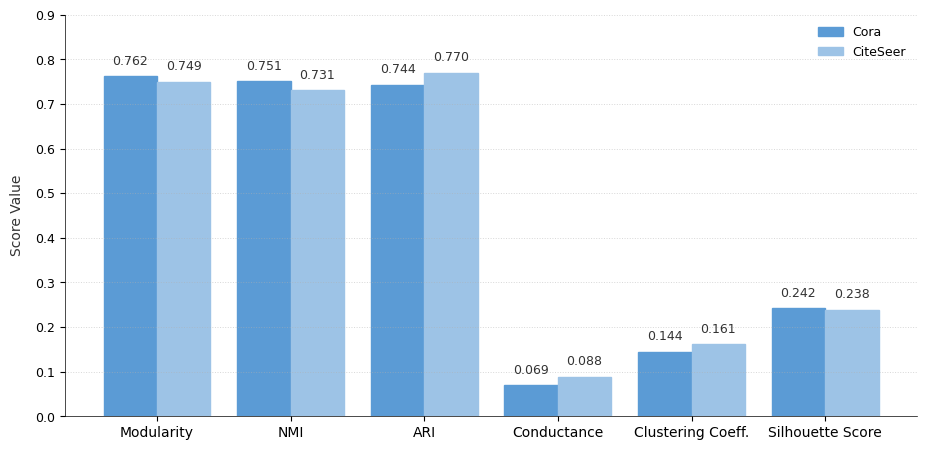

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set global font styles
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Evaluation metrics
metrics = {
    'Cora': {
        'Modularity': 0.7617,
        'NMI': 0.7508,
        'ARI': 0.7436,
        'Conductance': 0.0692,
        'Clustering Coeff.': 0.1443,
        'Silhouette Score': 0.2422
    },
    'CiteSeer': {
        'Modularity': 0.7494,
        'NMI': 0.7305,
        'ARI': 0.7696,
        'Conductance': 0.0878,
        'Clustering Coeff.': 0.1611,
        'Silhouette Score': 0.2383
    }
}

# Prepare data
metric_names = list(metrics['Cora'].keys())
cora_values = list(metrics['Cora'].values())
citeseer_values = list(metrics['CiteSeer'].values())

# Lighter blue palette
palette = {
    'Cora': '#5B9BD5',  # Soft cornflower blue
    'CiteSeer': '#9DC3E6',  # Very light powder blue
    'background': 'white',
    'text': '#333333'
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=palette['background'])  # Slightly taller for y-axis
fig.subplots_adjust(bottom=0.15)

# Bar plot parameters - ZERO SPACE
x = np.arange(len(metric_names))
width = 0.8  # Total width allocated per metric group

# Create adjacent bars
rects1 = ax.bar(x - width/4, cora_values, width/2,
                label='Cora', color=palette['Cora'],
                edgecolor=palette['Cora'])

rects2 = ax.bar(x + width/4, citeseer_values, width/2,
                label='CiteSeer', color=palette['CiteSeer'],
                edgecolor=palette['CiteSeer'])

# Axes customization - Y-AXIS RESTORED
ax.set_ylim(0, 0.9)
ax.set_yticks(np.arange(0, 1.0, 0.1))  # Y-axis ticks at 0.1 intervals
ax.tick_params(axis='y', labelsize=9)
ax.set_ylabel('Score Value', fontsize=10, color=palette['text'], labelpad=8)

# Light horizontal gridlines for y-axis reference
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Metric names
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10, rotation=0)

# Legend
legend = ax.legend(frameon=False, fontsize=9, loc='upper right')

# VALUE LABELS ABOVE BARS (retained)
def autolabel(rects, offset=0.02):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + offset,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=9, color=palette['text'])

autolabel(rects1)
autolabel(rects2)

# Save
plt.savefig('light_blues_with_both_values.png',
            dpi=400, bbox_inches='tight',
            facecolor=palette['background'])
plt.show()

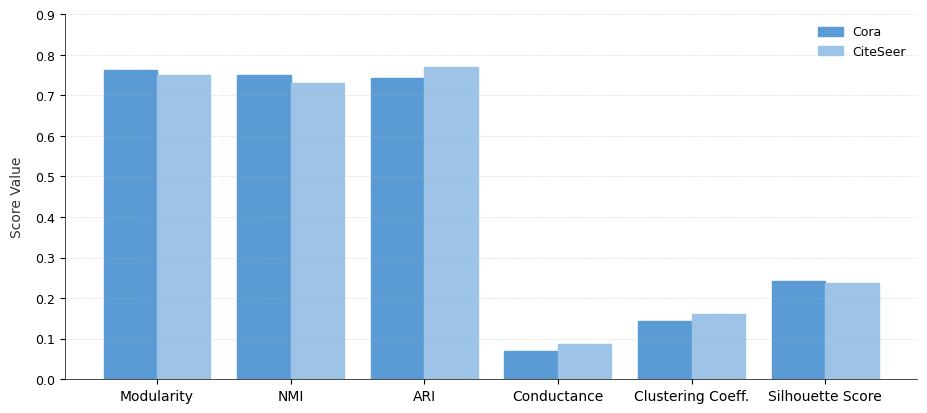

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set global font styles
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Evaluation metrics
metrics = {
    'Cora': {
        'Modularity': 0.7617,
        'NMI': 0.7508,
        'ARI': 0.7436,
        'Conductance': 0.0692,
        'Clustering Coeff.': 0.1443,
        'Silhouette Score': 0.2422
    },
    'CiteSeer': {
        'Modularity': 0.7494,
        'NMI': 0.7305,
        'ARI': 0.7696,
        'Conductance': 0.0878,
        'Clustering Coeff.': 0.1611,
        'Silhouette Score': 0.2383
    }
}

# Prepare data
metric_names = list(metrics['Cora'].keys())
cora_values = list(metrics['Cora'].values())
citeseer_values = list(metrics['CiteSeer'].values())

# Lighter blue palette
palette = {
    'Cora': '#5B9BD5',  # Soft cornflower blue
    'CiteSeer': '#9DC3E6',  # Very light powder blue
    'background': 'white',
    'text': '#333333'
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 5), facecolor=palette['background'])
fig.subplots_adjust(bottom=0.15)

# Bar plot parameters - ZERO SPACE
x = np.arange(len(metric_names))
width = 0.8  # Total width allocated per metric group

# Create adjacent bars
rects1 = ax.bar(x - width/4, cora_values, width/2,
                label='Cora', color=palette['Cora'],
                edgecolor=palette['Cora'])

rects2 = ax.bar(x + width/4, citeseer_values, width/2,
                label='CiteSeer', color=palette['CiteSeer'],
                edgecolor=palette['CiteSeer'])

# Axes customization
ax.set_ylim(0, 0.9)
ax.set_yticks(np.arange(0, 1.0, 0.1))  # Y-axis ticks at 0.1 intervals
ax.tick_params(axis='y', labelsize=9)
ax.set_ylabel('Score Value', fontsize=10, color=palette['text'], labelpad=8)

# Light horizontal gridlines for y-axis reference
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Metric names
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10, rotation=0)

# Legend
legend = ax.legend(frameon=False, fontsize=9, loc='upper right')

# REMOVED THE autolabel() FUNCTION AND ITS CALLS

# Save
plt.savefig('light_blues_yaxis_only.png',
            dpi=400, bbox_inches='tight',
            facecolor=palette['background'])
plt.show()

LOUVAIN ALGORITHM

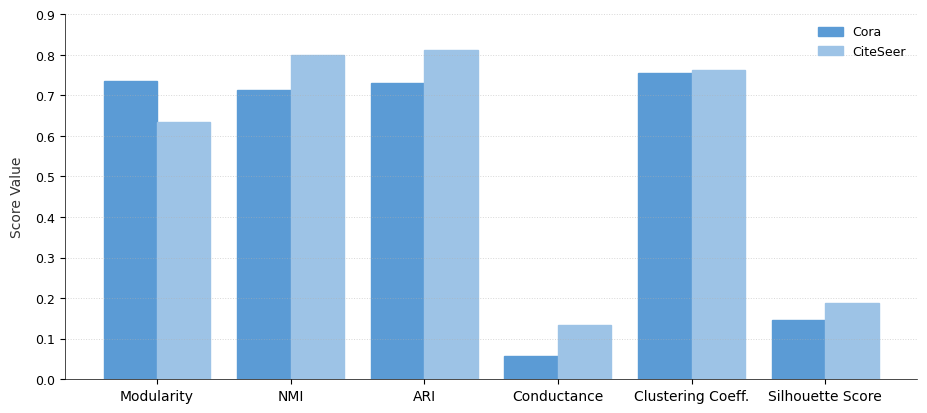

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set global font styles
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Evaluation metrics
metrics = {
    'Cora': {
        'Modularity': 0.7357,
        'NMI': 0.7130 ,
        'ARI':  0.7305 ,
        'Conductance':  0.0571 ,
        'Clustering Coeff.':  0.7540,
        'Silhouette Score': 0.1461
    },
    'CiteSeer': {
        'Modularity': 0.6334,
        'NMI': 0.7987,
        'ARI': 0.8128,
        'Conductance': 0.1343,
        'Clustering Coeff.':  0.7627,
        'Silhouette Score':  0.1875
    }
}

# Prepare data
metric_names = list(metrics['Cora'].keys())
cora_values = list(metrics['Cora'].values())
citeseer_values = list(metrics['CiteSeer'].values())

# Lighter blue palette
palette = {
    'Cora': '#5B9BD5',  # Soft cornflower blue
    'CiteSeer': '#9DC3E6',  # Very light powder blue
    'background': 'white',
    'text': '#333333'
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 5), facecolor=palette['background'])
fig.subplots_adjust(bottom=0.15)

# Bar plot parameters - ZERO SPACE
x = np.arange(len(metric_names))
width = 0.8  # Total width allocated per metric group

# Create adjacent bars
rects1 = ax.bar(x - width/4, cora_values, width/2,
                label='Cora', color=palette['Cora'],
                edgecolor=palette['Cora'])

rects2 = ax.bar(x + width/4, citeseer_values, width/2,
                label='CiteSeer', color=palette['CiteSeer'],
                edgecolor=palette['CiteSeer'])

# Axes customization
ax.set_ylim(0, 0.9)
ax.set_yticks(np.arange(0, 1.0, 0.1))  # Y-axis ticks at 0.1 intervals
ax.tick_params(axis='y', labelsize=9)
ax.set_ylabel('Score Value', fontsize=10, color=palette['text'], labelpad=8)

# Light horizontal gridlines for y-axis reference
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Metric names
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10, rotation=0)

# Legend
legend = ax.legend(frameon=False, fontsize=9, loc='upper right')

# REMOVED THE autolabel() FUNCTION AND ITS CALLS

# Save
plt.savefig('light_blues_yaxis_only.png',
            dpi=400, bbox_inches='tight',
            facecolor=palette['background'])
plt.show()

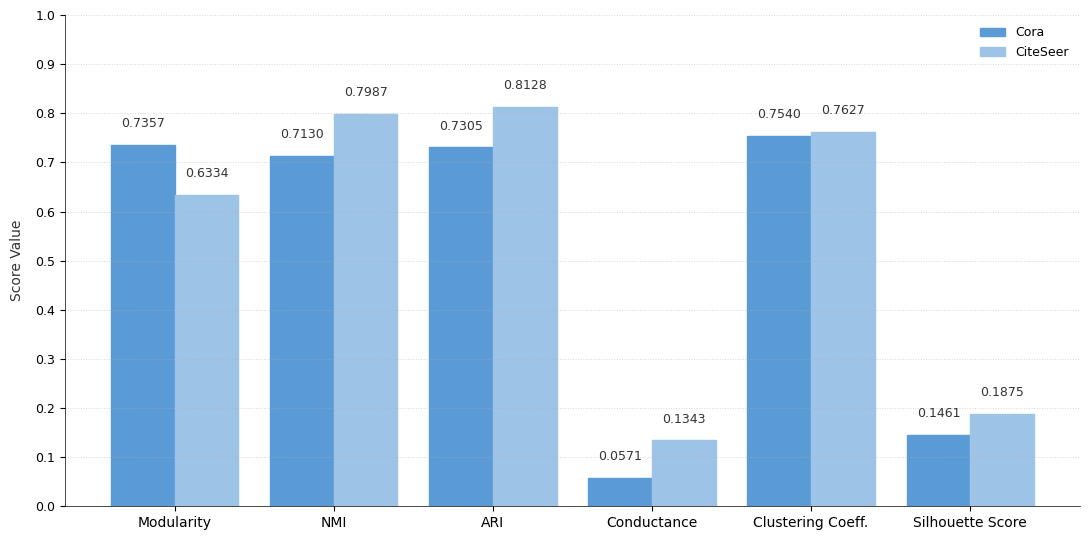

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Set global font styles
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

# Evaluation metrics
metrics = {
    'Cora': {
        'Modularity': 0.7357,
        'NMI': 0.7130,
        'ARI': 0.7305,
        'Conductance': 0.0571,
        'Clustering Coeff.': 0.7540,
        'Silhouette Score': 0.1461
    },
    'CiteSeer': {
        'Modularity': 0.6334,
        'NMI': 0.7987,
        'ARI': 0.8128,
        'Conductance': 0.1343,
        'Clustering Coeff.': 0.7627,
        'Silhouette Score': 0.1875
    }
}

# Prepare data
metric_names = list(metrics['Cora'].keys())
cora_values = list(metrics['Cora'].values())
citeseer_values = list(metrics['CiteSeer'].values())

# Lighter blue palette
palette = {
    'Cora': '#5B9BD5',  # Soft cornflower blue
    'CiteSeer': '#9DC3E6',  # Very light powder blue
    'background': 'white',
    'text': '#333333'
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=palette['background'])  # Slightly taller for values
fig.subplots_adjust(bottom=0.15)

# Bar plot parameters - ZERO SPACE
x = np.arange(len(metric_names))
width = 0.8  # Total width allocated per metric group

# Create adjacent bars
rects1 = ax.bar(x - width/4, cora_values, width/2,
                label='Cora', color=palette['Cora'],
                edgecolor=palette['Cora'])

rects2 = ax.bar(x + width/4, citeseer_values, width/2,
                label='CiteSeer', color=palette['CiteSeer'],
                edgecolor=palette['CiteSeer'])

# Axes customization
ax.set_ylim(0, 1.0)  # Increased to accommodate values above bars
ax.set_yticks(np.arange(0, 1.1, 0.1))  # Y-axis ticks at 0.1 intervals
ax.tick_params(axis='y', labelsize=9)
ax.set_ylabel('Score Value', fontsize=10, color=palette['text'], labelpad=8)

# Light horizontal gridlines for y-axis reference
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Metric names
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=10, rotation=0)

# Legend
legend = ax.legend(frameon=False, fontsize=9, loc='upper right')

# ADDED: Value labels above bars
def autolabel(rects, offset=0.03):  # Increased offset slightly
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + offset,
                f'{height:.4f}',  # 4 decimal places for precision
                ha='center', va='bottom',
                fontsize=9, color=palette['text'])

autolabel(rects1)
autolabel(rects2)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save
plt.savefig('light_blues_with_bar_values.png',
            dpi=400, bbox_inches='tight',
            facecolor=palette['background'])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import ListedColormap

# Create custom colormap (blue for in-clique, light gray for non-clique)
colors = ['#E0E0E0', '#5B9BD5']  # [not in clique, in clique]
cmap = ListedColormap(colors)

# Prepare data for scatter plot
nodes = list(G.nodes())
x = [pos[node][0] for node in nodes]  # X coordinates from spring layout
y = [pos[node][1] for node in nodes]  # Y coordinates from spring layout
membership = [k_clique_membership[node] for node in nodes]  # 0 or 1

# Create figure
plt.figure(figsize=(12, 10))

# Scatter plot with color-coded membership
scatter = plt.scatter(x, y,
                      c=membership,
                      cmap=cmap,
                      s=30,
                      alpha=0.8,
                      edgecolors='white',
                      linewidths=0.3)

# Add edges (light gray for visibility)
for edge in G_clique.edges():
    plt.plot([pos[edge[0]][0], pos[edge[1]][0]],
             [pos[edge[0]][1], pos[edge[1]][1]],
             color='#B0B0B0', linewidth=0.5, alpha=0.3)

# Custom legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='In k-Clique',
               markerfacecolor='#5B9BD5', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Not in k-Clique',
               markerfacecolor='#E0E0E0', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', frameon=False)

# Add title and info box
plt.title(f'k-Clique Community Detection (k={k})\n'
          f'Nodes in clique: {membership_distribution["In k-Clique (1)"]} | '
          f'Nodes not in clique: {membership_distribution["Not in k-Clique (0)"]}',
          pad=20)

# Remove axes for cleaner look
plt.axis('off')

# Save and show
plt.tight_layout()
plt.savefig('k_clique_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

KeyError: 35